### Clustering Project: Topic Discovery on News Articles (AG News)

Goal: Discover natural topic clusters from news article text using unsupervised learning.

Core ideas covered:

Text cleaning → TF-IDF (with bigrams) → optional SVD (LSA)

K-Means clustering (plus optional MiniBatchKMeans/Agglomerative)

Choosing K via elbow/inertia & silhouette

Internal metrics: silhouette, Calinski–Harabasz, Davies–Bouldin

External metrics (for class demo only): ARI, NMI vs true labels

Cluster interpretation: top terms, representative documents

2D visualization (t-SNE on SVD features)

Predicting a cluster for new, unseen text

In a true unsupervised setting, you wouldn’t have labels. 
Here we’ll use AG News labels only to demonstrate external validation 
(how “close” our clusters are to the gold topics).

### Setup & Data Loading

In [1]:
# !pip install datasets scikit-learn textblob matplotlib
# (Optional) !pip install umap-learn  # if you want to try UMAP

import re, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
from textblob import TextBlob

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

USE_HF = True  # set False to use CSV path


In [2]:

if USE_HF:
    from datasets import load_dataset
    ds = load_dataset("ag_news")
    # Build pandas DataFrames
    df_train = pd.DataFrame(ds['train'])
    df_test  = pd.DataFrame(ds['test'])
    # Concatenate for unsupervised clustering (more data = better clusters)
    df = pd.concat([df_train, df_test], ignore_index=True)
    # ds has columns: ['text','label']; no titles/descriptions split here
    df['raw_text'] = df['text'].astype(str)
    label_names = ["World", "Sports", "Business", "Sci/Tech"]
    df['label_name'] = df['label'].map(lambda i: label_names[i])


README.md: 0.00B [00:00, ?B/s]

c:\Users\mindf\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mindf\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [5]:
# Sanity Checks

In [3]:
print(df.shape)
df[['raw_text','label','label_name']].head(3)


(127600, 4)


,raw_text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business


In [4]:
N = 40000  # pick 20k–60k for quick runs; full ~127.6k rows
if len(df) > N:
    df = df.sample(N, random_state=RANDOM_STATE).reset_index(drop=True)


In [6]:
### Text Cleaning & Lightweight Feature Signals

In [7]:
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"<.*?>", " ", s)           # remove HTML
    s = re.sub(r"[^a-z\s]", " ", s)        # keep letters/spaces
    s = re.sub(r"\s+", " ", s).strip()
    return s

df['clean'] = df['raw_text'].astype(str).apply(clean_text)
df['char_len'] = df['clean'].apply(len)
df['word_count'] = df['clean'].apply(lambda x: len(x.split()))
df['excl_count'] = df['raw_text'].apply(lambda x: x.count('!'))
# sentiment polarity is optional (fast enough for lines of text)
df['polarity'] = df['clean'].apply(lambda x: TextBlob(x).sentiment.polarity if x else 0.0)

df[['clean','char_len','word_count','excl_count','polarity']].head(3)


,clean,char_len,word_count,excl_count,polarity
0,no georgia tech arkansas little rock georgia t...,223,39,0,-0.064583
1,carter s got nothing to say after scoring afte...,226,43,0,0.050000
2,adobe offers standard for raw photo formats th...,168,28,0,-0.002426


### Vectorization (TF-IDF) + Optional Dimensionality Reduction (SVD)

Why SVD (a.k.a. LSA)?

TF-IDF can be 10k+ dimensions (sparse).

SVD projects to a dense low-rank semantic space (e.g., 100 dims) → faster clustering, less noise.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Tune these for your machine
MAX_FEATS = 10000
SVD_COMPONENTS = 100  # set to None to skip SVD

vectorizer = TfidfVectorizer(max_features=MAX_FEATS,
                             ngram_range=(1,2),
                             stop_words='english')
X_tfidf = vectorizer.fit_transform(df['clean'])

if SVD_COMPONENTS and SVD_COMPONENTS > 0:
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
    X = svd.fit_transform(X_tfidf)  # dense array (n_samples, SVD_COMPONENTS)
else:
    X = X_tfidf  # sparse


### Choosing the Number of Clusters (K)

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 10)
inertias, sils = [], []

for k in Ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE)
    km.fit(X)
    inertias.append(km.inertia_)
    # silhouette needs >1 cluster, works with dense/sparse
    sil = silhouette_score(X if hasattr(X, "toarray")==False else X, km.labels_)
    sils.append(sil)

print(list(zip(Ks, inertias, sils)))


[(2, 4994.727929159706, 0.3150074690236186), (3, 4879.602647494445, 0.17374213610740977), (4, 4741.106128356524, 0.09223402663932975), (5, 4700.488836219736, 0.09438880878553377), (6, 4681.4872383175525, 0.054821439405944104), (7, 4613.3497774657335, 0.019001942267530582), (8, 4390.429885100735, 0.10051123168121123), (9, 4351.888560404579, 0.09705768422428482)]


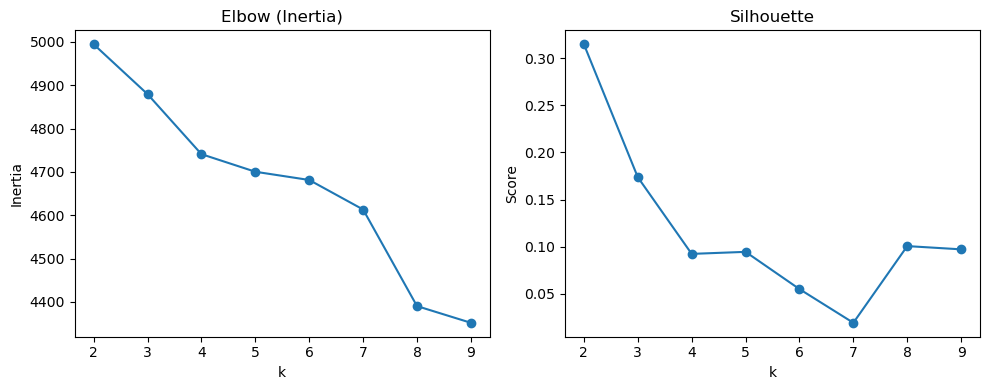

In [10]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(Ks, inertias, marker='o'); plt.title("Elbow (Inertia)"); plt.xlabel("k"); plt.ylabel("Inertia")
plt.subplot(1,2,2); plt.plot(Ks, sils, marker='o'); plt.title("Silhouette"); plt.xlabel("k"); plt.ylabel("Score")
plt.tight_layout(); plt.show()


### Internal Metrics (Unsupervised Quality)

In [14]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

sil = silhouette_score(X, km.labels_)
ch  = calinski_harabasz_score(X, km.labels_)
db  = davies_bouldin_score(X, km.labels_)

print(f"Silhouette: {sil:.3f} | Calinski-Harabasz: {ch:.0f} | Davies-Bouldin: {db:.3f}")


Silhouette: 0.097 | Calinski-Harabasz: 1047 | Davies-Bouldin: 2.932


Interpretation:

Silhouette ∈ [−1, 1]; higher = better separation.

Calinski–Harabasz: higher = better defined clusters.

Davies–Bouldin: lower = better (less overlap/compactness).

### Interpreting Clusters

Top Terms per Cluster (from TF-IDF space)

Clustering on SVD is great for performance, but top terms are easier to read from the TF-IDF space. We’ll fit a light MiniBatchKMeans on X_tfidf to extract vocabulary-level centroids and top words.

In [15]:
from sklearn.cluster import MiniBatchKMeans

K = 10
mbk = MiniBatchKMeans(n_clusters=K, random_state=RANDOM_STATE, batch_size=2048, n_init='auto')
mbk.fit(X_tfidf)
order_centroids = mbk.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

TOP_N = 15
cluster_top_terms = []
for i in range(K):
    top_terms = [terms[ind] for ind in order_centroids[i, :TOP_N]]
    cluster_top_terms.append(top_terms)
    print(f"\nCluster {i} top terms:\n", ", ".join(top_terms))



Cluster 0 top terms:
 quot, game, season, league, coach, sox, win, night, new, red, team, red sox, yankees, sports, victory

Cluster 1 top terms:
 ap, ap ap, bush, said, new, night, president, kerry, game, thursday, wednesday, sunday, friday, tuesday, year

Cluster 2 top terms:
 iraq, killed, baghdad, iraqi, minister, said, afp, troops, people, police, prime minister, prime, al, bomb, canadian

Cluster 3 top terms:
 oil, prices, oil prices, stocks, crude, barrel, reuters, crude oil, new, record, higher, high, new york, york, supply

Cluster 4 top terms:
 new, said, year, company, million, yesterday, space, today, monday, billion, years, says, quarter, time, week

Cluster 5 top terms:
 microsoft, software, google, search, windows, internet, mobile, new, corp, intel, web, quote, research, security, service

Cluster 6 top terms:
 reuters, reuters reuters, bush, palestinian, gaza, said, arafat, israeli, president, israel, nuclear, iran, yasser, kerry, yasser arafat

Cluster 7 top terms:
 

Representative Documents per Cluster

Find the documents closest to each centroid in the SVD space (fast and usually meaningful).

In [17]:
from sklearn.metrics import pairwise_distances_argmin_min

closest, _ = pairwise_distances_argmin_min(km.cluster_centers_, X)
for i, doc_idx in enumerate(closest):
    print(f"\nCluster {i} representative doc:")
    print(df.iloc[doc_idx]['raw_text'][:300], "...")



Cluster 0 representative doc:
Knauss Tests Positive for Nandrolone  VIENNA (Reuters) - Austrian skier Hans Knauss, 33, has  tested positive for the anabolic steroid nandrolone. ...

Cluster 1 representative doc:
Gannon No Longer Wearing Neck Brace (AP) AP - Rich Gannon no longer needs a bulky, plastic brace to protect the broken vertebra in his neck. ...

Cluster 2 representative doc:
Product Review: Nokia 6820 Wireless Messaging Handset (NewsFactor) NewsFactor - The Nokia (NYSE: NOK) 6820 is an ergonomically pleasing handheld device that integrates short text, multimedia and \instant messaging capabilities with all of the features and functions that one normally would expect to  ...

Cluster 3 representative doc:
Oil little changed, ponders winter weather SINGAPORE, NOV 19: Oil prices were little changed on Friday as traders waited to see whether the onset of the northern winter will put a squeeze on low heating fuel stocks. ...

Cluster 4 representative doc:
Before-the-Bell: Accredo

### 2D Visualization

We’ll use t-SNE on the SVD features to plot clusters. (UMAP is another good option.)

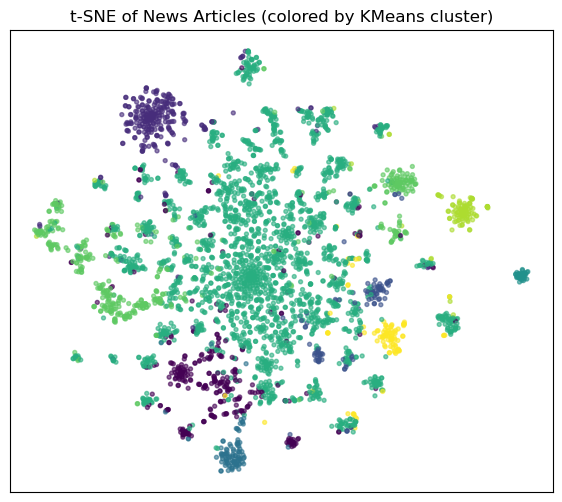

In [19]:
from sklearn.manifold import TSNE

# t-SNE can be slow; sample if needed
N_VIS = 4000
idx = np.random.choice(len(df), size=min(N_VIS, len(df)), replace=False)
X_vis = X[idx]
labels_vis = km.labels_[idx]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', learning_rate='auto', perplexity=30)
X_2d = tsne.fit_transform(X_vis)

plt.figure(figsize=(7,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_vis, s=8, alpha=0.6)
plt.title("t-SNE of News Articles (colored by KMeans cluster)")
plt.xticks([]); plt.yticks([])
plt.show()


### Predicting a Cluster for New Text

Create a small helper to assign a cluster to new, unseen text:

In [21]:
def predict_cluster(text: str):
    txt = clean_text(text or "")
    X_new_tfidf = vectorizer.transform([txt])
    X_new = svd.transform(X_new_tfidf) if 'svd' in globals() and svd is not None else X_new_tfidf
    cl = km.predict(X_new)[0]
    return {
        "cluster_id": int(cl),
        "top_terms": cluster_top_terms[cl],
    }

example = "Shares surge as tech companies announce record quarterly earnings"
predict_cluster(example)


{'cluster_id': 0,
 'top_terms': ['quot',
  'game',
  'season',
  'league',
  'coach',
  'sox',
  'win',
  'night',
  'new',
  'red',
  'team',
  'red sox',
  'yankees',
  'sports',
  'victory']}

### Variants & Extensions - try these

Agglomerative clustering with cosine distance on SVD features; compare to KMeans.

HDBSCAN (if allowed) to discover variable-density clusters and auto-estimate the number of clusters.

No SVD: Cluster directly on TF-IDF (use MiniBatchKMeans for efficiency); compare inertia/silhouette.

N-grams & stopword tweaks: try (1,3) n-grams, or custom stopword lists.

Embeddings: Replace TF-IDF with sentence embeddings (e.g., sentence-transformers); then cluster in embedding space and compare ARI/NMI.

Topic modeling: Try NMF or LDA and compare topics vs clusters.

Cluster labeling: programmatically label clusters using top terms or class probabilities from a downstream classifier.

### Quick Reference

Why TF-IDF? Sparse bag-of-words baseline that’s interpretable and strong.

Why SVD? Reduces noise and dimensionality; speeds up clustering; captures latent semantics.

How to pick K? Use a mix of inertia (elbow) and silhouette; also inspect top terms and samples.

Internal vs External metrics: Internal (silhouette/CH/DB) are true unsupervised; external (ARI/NMI) require labels and are used here just to evaluate how well clusters align with known topics.

Interpretability: Top terms + representative docs ground each cluster in human-readable summaries.